In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans

In [2]:
dataset = pd.read_csv("../assets/csv-files/iris-flower.csv")
dataset.head(3)

,Sepal Length,Sepal Width,Petal Length,Petal Width,Species
0,5.1,3.5,1.4,0.2,Setosa
1,4.9,3.0,1.4,0.2,Setosa
2,4.7,3.2,1.3,0.2,Setosa


In [3]:
# Our data is labeled 
# For unsuperivised learning we need unlabeled data
# So lets remove Species column and make it unlabeled
dataset.drop(columns="Species", inplace=True)
dataset.head(3)

,Sepal Length,Sepal Width,Petal Length,Petal Width
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2


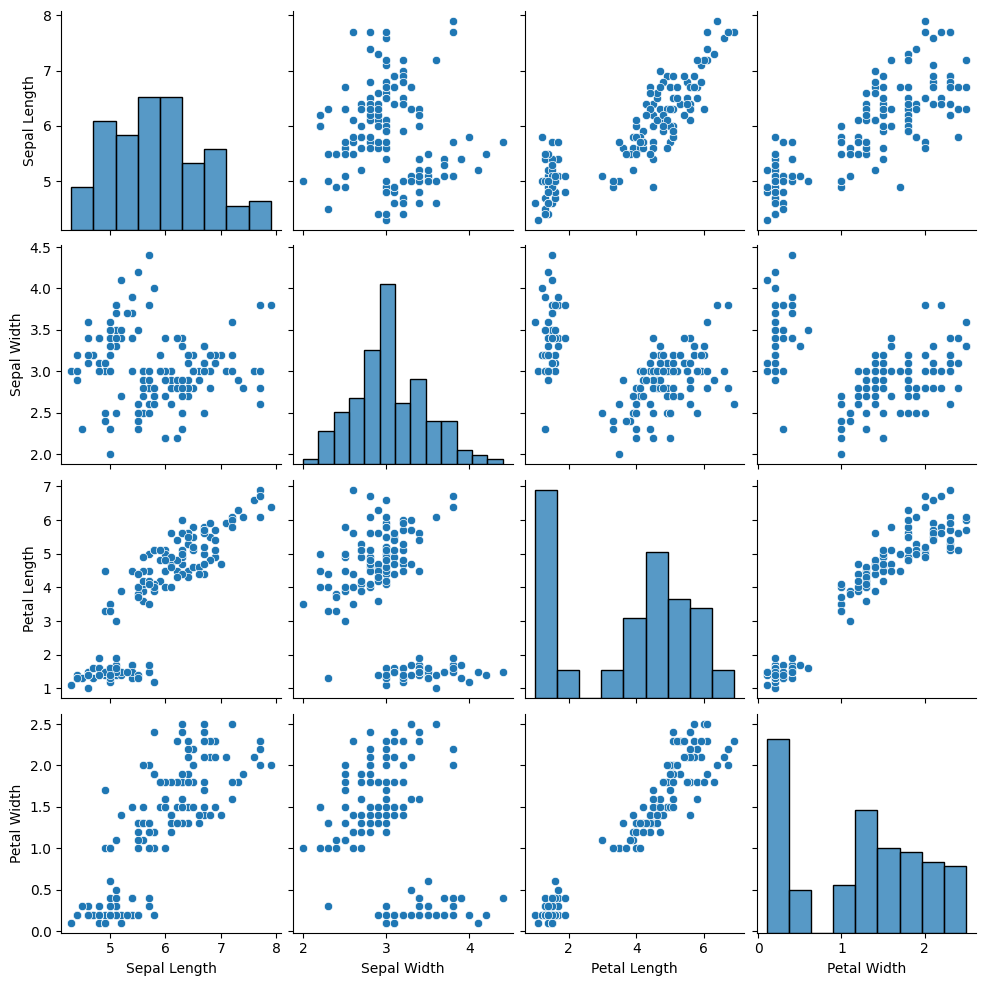

In [4]:
# Visualize the dataset
sns.pairplot(data=dataset)
plt.show()

In [5]:
# Silhouette score to find best number of clusters
from sklearn.metrics import silhouette_score

In [6]:
# Find best number of clusters
ss = []
for i in range(2, 21):
    km = KMeans(n_clusters=i)
    km.fit(dataset)
    ss.append(silhouette_score(dataset, labels=km.labels_))

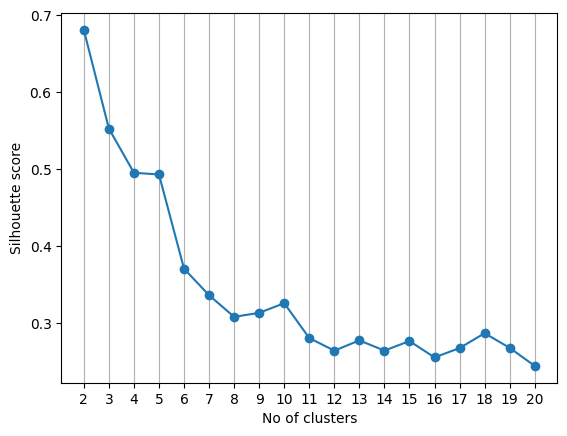

'The best number of clusters is found to be 2'

In [7]:
# Create a graph between ss and number of clusters
no_of_clusters = [i for i in range(2, 21)]
plt.plot(no_of_clusters, ss, marker="o")
plt.xlabel("No of clusters")
plt.xticks(no_of_clusters)
plt.ylabel("Silhouette score")
plt.grid(axis="x")
plt.show()
'''The best number of clusters is found to be 2'''

In [8]:
# Train model using best number of clusters
km = KMeans(n_clusters=2)
km.fit(dataset)

KMeans(n_clusters=2)

In [9]:
# Add the Predict value to dataset for visualization
dataset["Predict"] = km.predict(dataset)
dataset.head(3)

,Sepal Length,Sepal Width,Petal Length,Petal Width,Predict
0,5.1,3.5,1.4,0.2,1
1,4.9,3.0,1.4,0.2,1
2,4.7,3.2,1.3,0.2,1


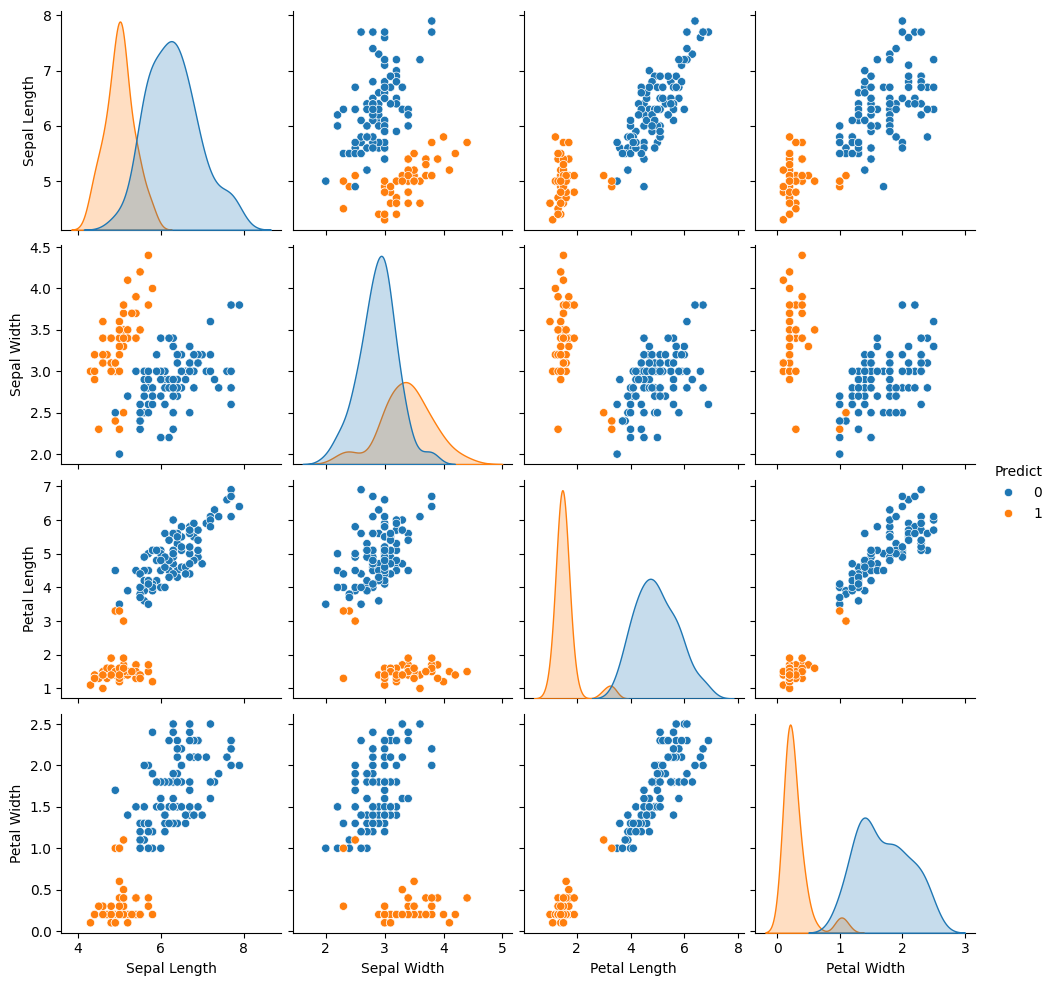

In [10]:
# Visualize the clusters
sns.pairplot(dataset, hue="Predict")
plt.show()